# PCA mit Schiffen
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  


---

## 🎯 Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- den **vollständigen PCA-Workflow** (Laden → Skalieren → PCA → Klassifizieren → Vorhersagen) auf einen neuen Datensatz anwenden
- `explained_variance_ratio_` korrekt interpretieren
- erklären, **warum** neue Datenpunkte mit denselben `StandardScaler`- und `PCA`-Objekten transformiert werden müssen
- einschätzen, wann eine einzige Hauptkomponente ausreicht

---

## 📖 Kontext

Dieses Notebook ist die **Einstiegs-Anwendung** für PCA. Wir arbeiten mit einem kleinen, anschaulichen Datensatz: **6 Schiffe**, beschrieben durch ihre *Länge (m)* und *Verdrängung (t)*.

**Kernfrage:** Reicht eine einzige Zahl (statt zwei Features) aus, um Schiffe korrekt zu klassifizieren?


---
## Schritt 1: Daten laden und visualisieren

Wir haben 6 Schiffe mit zwei Merkmalen: **Länge** und **Verdrängung**. Beides misst im Prinzip dasselbe – die Größe eines Schiffes. Das nennt man **Korrelation**.

**Beobachten Sie im Plot:** Liegen die Punkte eher auf einer Linie oder verstreut?

 Nr  Länge (m)  Verdrängung (t)             Typ
  1        313            71485    Frachtschiff
  2        269            53752 Passagierschiff
  3        245            42124 Passagierschiff
  4        332            97875    Frachtschiff
  5        312            75364    Frachtschiff
  6        211            32157 Passagierschiff


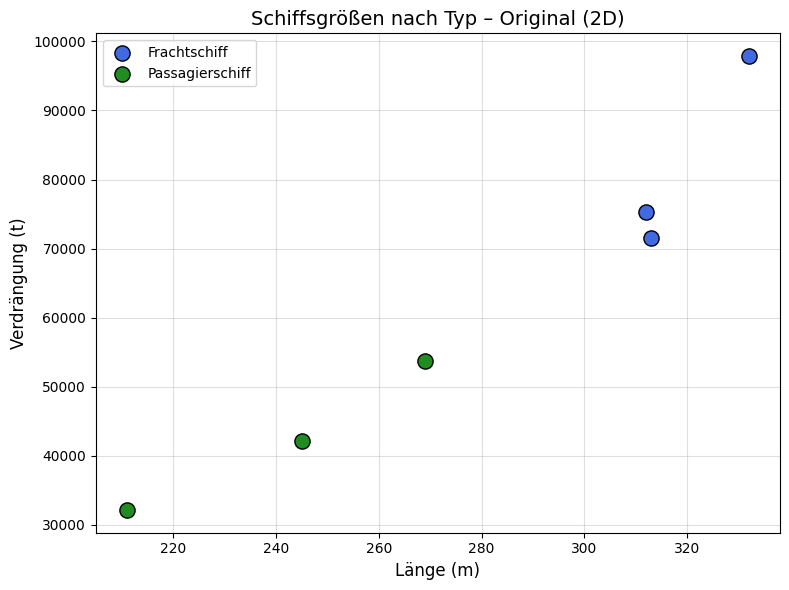


📊 Datensatz: 6 Schiffe, 2 Features
Korrelation Länge ↔ Verdrängung: 0.9671


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Datensatz definieren
data = {
    'Nr': [1, 2, 3, 4, 5, 6],
    'Länge (m)': [313, 269, 245, 332, 312, 211],
    'Verdrängung (t)': [71485, 53752, 42124, 97875, 75364, 32157],
    'Typ': ['Frachtschiff', 'Passagierschiff', 'Passagierschiff',
            'Frachtschiff', 'Frachtschiff', 'Passagierschiff']
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

# Labels kodieren: 0 = Frachtschiff, 1 = Passagierschiff
X = df[['Länge (m)', 'Verdrängung (t)']].values
y = (df['Typ'] == 'Passagierschiff').astype(int).values

# Plot
farben = {'Frachtschiff': 'royalblue', 'Passagierschiff': 'forestgreen'}
plt.figure(figsize=(8, 6))
for typ in df['Typ'].unique():
    subset = df[df['Typ'] == typ]
    plt.scatter(subset['Länge (m)'], subset['Verdrängung (t)'],
                label=typ, color=farben[typ], s=120, edgecolors='black')

plt.xlabel('Länge (m)', fontsize=12)
plt.ylabel('Verdrängung (t)', fontsize=12)
plt.title('Schiffsgrößen nach Typ – Original (2D)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n📊 Datensatz: {X.shape[0]} Schiffe, {X.shape[1]} Features")
print(f"Korrelation Länge ↔ Verdrängung: {np.corrcoef(X[:,0], X[:,1])[0,1]:.4f}")

---
## Schritt 2: Datenstandardisierung mit StandardScaler

**Warum ist das notwendig?**  
PCA ist **varianzbasiert** – es findet die Richtung mit der größten Streuung. Wenn ein Feature Werte in Zehntausenden hat (Verdrängung) und ein anderes in Hunderten (Länge), dominiert das größere Feature die Analyse – obwohl es nicht unbedingt informativer ist.

> **Merksatz:** StandardScaler → Mittelwert = 0, Standardabweichung = 1 → alle Features gleichwertig

**Wichtig:** Wir wenden `fit_transform` nur auf den Trainingsdaten an. Neue Datenpunkte werden später nur mit `transform` transformiert!

Originaldaten (erste 3 Zeilen):
[[  313 71485]
 [  269 53752]
 [  245 42124]]

Nach StandardScaler (erste 3 Zeilen):
[[ 0.7656  0.425 ]
 [-0.2656 -0.3803]
 [-0.8281 -0.9084]]

Mittelwert nach Skalierung: [0. 0.]
Standardabweichung nach Skalierung: [1. 1.]


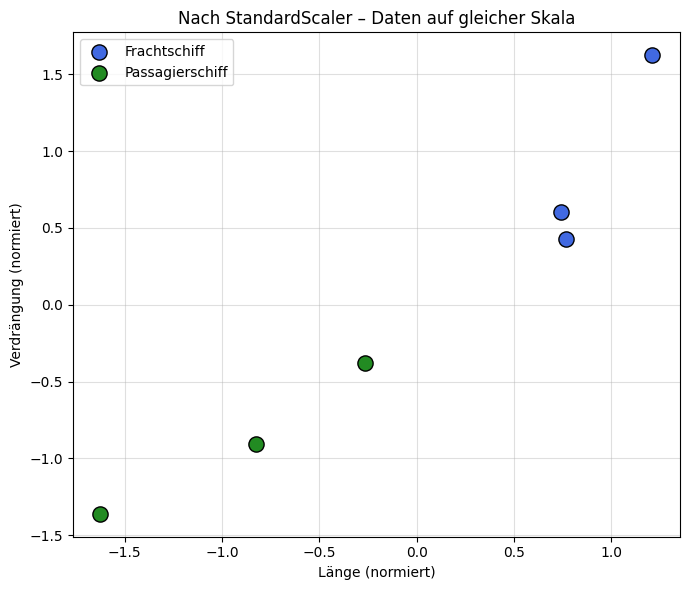

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit UND transform in einem Schritt

print("Originaldaten (erste 3 Zeilen):")
print(X[:3])
print("\nNach StandardScaler (erste 3 Zeilen):")
print(X_scaled[:3].round(4))
print(f"\nMittelwert nach Skalierung: {X_scaled.mean(axis=0).round(6)}")
print(f"Standardabweichung nach Skalierung: {X_scaled.std(axis=0).round(6)}")

# Visualisierung der skalierten Daten
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[y==0][:, 0], X_scaled[y==0][:, 1],
            label='Frachtschiff', color='royalblue', s=120, edgecolors='black')
plt.scatter(X_scaled[y==1][:, 0], X_scaled[y==1][:, 1],
            label='Passagierschiff', color='forestgreen', s=120, edgecolors='black')
plt.xlabel('Länge (normiert)')
plt.ylabel('Verdrängung (normiert)')
plt.title('Nach StandardScaler – Daten auf gleicher Skala')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Schritt 3: PCA anwenden – von 2D auf 1D

Wir reduzieren von 2 Features auf **1 Hauptkomponente**. Die Frage ist: Wie viel Information bleibt erhalten?

Das zeigt uns `explained_variance_ratio_`:

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(X_scaled)
X_scaled_compressed = pca.transform(X_scaled)

print(f"Originaldaten:     {X_scaled.shape}  (2D)")
print(f"Nach PCA:          {X_scaled_compressed.shape}  (1D)")
print()
print(f"explained_variance_ratio_ = {pca.explained_variance_ratio_}")
print(f"→ PC1 erklärt {pca.explained_variance_ratio_[0]*100:.2f} % der Gesamtvarianz")
print(f"→ Informationsverlust: nur {(1 - pca.explained_variance_ratio_[0])*100:.2f} %")
print()
print("Die 1D-Darstellung der Schiffe (PC1-Wert):")
for i, (val, typ) in enumerate(zip(X_scaled_compressed.flatten(), df['Typ'])):
    print(f"  Schiff {i+1} ({typ:>15s}): PC1 = {val:+.4f}")

Originaldaten:     (6, 2)  (2D)
Nach PCA:          (6, 1)  (1D)

explained_variance_ratio_ = [0.98352646]
→ PC1 erklärt 98.35 % der Gesamtvarianz
→ Informationsverlust: nur 1.65 %

Die 1D-Darstellung der Schiffe (PC1-Wert):
  Schiff 1 (   Frachtschiff): PC1 = +0.8419
  Schiff 2 (Passagierschiff): PC1 = -0.4567
  Schiff 3 (Passagierschiff): PC1 = -1.2279
  Schiff 4 (   Frachtschiff): PC1 = +2.0042
  Schiff 5 (   Frachtschiff): PC1 = +0.9499
  Schiff 6 (Passagierschiff): PC1 = -2.1114


---
## Schritt 4: Klassifizierer auf den komprimierten Daten trainieren

Jetzt trainieren wir eine **logistische Regression** – aber nur auf den 1D-PCA-Daten statt den originalen 2D-Daten.

In [4]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42)
clf.fit(X_scaled_compressed, y)

# Trainingsergebnisse überprüfen
y_pred_train = clf.predict(X_scaled_compressed)
print("Vorhersagen auf Trainingsdaten:")
for i, (pred, true) in enumerate(zip(y_pred_train, y)):
    status = '✅' if pred == true else '❌'
    typ_pred = 'Passagierschiff' if pred == 1 else 'Frachtschiff'
    typ_true = 'Passagierschiff' if true == 1 else 'Frachtschiff'
    print(f"  Schiff {i+1}: {status} Vorhergesagt: {typ_pred:<16s} | Wahr: {typ_true}")

print(f"\nTrainingsgenauigkeit: {clf.score(X_scaled_compressed, y)*100:.0f}%")

Vorhersagen auf Trainingsdaten:
  Schiff 1: ✅ Vorhergesagt: Frachtschiff     | Wahr: Frachtschiff
  Schiff 2: ✅ Vorhergesagt: Passagierschiff  | Wahr: Passagierschiff
  Schiff 3: ✅ Vorhergesagt: Passagierschiff  | Wahr: Passagierschiff
  Schiff 4: ✅ Vorhergesagt: Frachtschiff     | Wahr: Frachtschiff
  Schiff 5: ✅ Vorhergesagt: Frachtschiff     | Wahr: Frachtschiff
  Schiff 6: ✅ Vorhergesagt: Passagierschiff  | Wahr: Passagierschiff

Trainingsgenauigkeit: 100%


---
## Schritt 5: Vorhersage für ein neues Schiff

**Ein neues Schiff** soll klassifiziert werden:  
- Länge: **260 m**  
- Verdrängung: **40.000 t**

> **Schlüsselfrage:** Warum MÜSSEN wir denselben `scaler` und dasselbe `pca`-Objekt verwenden – und keinen neuen?

**Antwort:** Der `StandardScaler` hat die Mittelwerte und Standardabweichungen der *Trainingsdaten* gelernt. Würden wir für das neue Schiff einen neuen Scaler erstellen, würde es auf einer anderen Skala liegen als die Trainingsdaten – das Modell würde inkonsistente Eingaben erhalten.

In [5]:
# Neues Schiff: Länge 260 m, Verdrängung 40.000 t
x_new = np.array([[260, 40000]])

# Schritt A: Mit dem TRAINIERTEN Scaler transformieren (nur transform, kein fit!)
x_new_scaled = scaler.transform(x_new)
print(f"Neues Schiff (original):    Länge={x_new[0,0]} m, Verdrängung={x_new[0,1]} t")
print(f"Neues Schiff (skaliert):    {x_new_scaled[0].round(4)}")

# Schritt B: Mit dem TRAINIERTEN PCA-Modell transformieren (nur transform!)
x_new_compressed = pca.transform(x_new_scaled)
print(f"Neues Schiff (PCA, 1D):     PC1 = {x_new_compressed[0,0]:.4f}")

# Schritt C: Klassifikation
prediction = clf.predict(x_new_compressed)
prob = clf.predict_proba(x_new_compressed)

typ = 'Passagierschiff' if prediction[0] == 1 else 'Frachtschiff'
print(f"\n🚢 Vorhersage: Das neue Schiff ist ein {typ}")
print(f"   Wahrscheinlichkeit Frachtschiff:   {prob[0,0]*100:.1f}%")
print(f"   Wahrscheinlichkeit Passagierschiff: {prob[0,1]*100:.1f}%")

Neues Schiff (original):    Länge=260 m, Verdrängung=40000 t
Neues Schiff (skaliert):    [-0.4765 -1.0048]
Neues Schiff (PCA, 1D):     PC1 = -1.0475

🚢 Vorhersage: Das neue Schiff ist ein Passagierschiff
   Wahrscheinlichkeit Frachtschiff:   21.7%
   Wahrscheinlichkeit Passagierschiff: 78.3%


---
## Zusammenfassung des Workflows

```
Rohdaten (2D)
    → StandardScaler.fit_transform()   → skalierte Daten (2D)
    → PCA.fit_transform()             → komprimierte Daten (1D)
    → LogisticRegression.fit()        → trainiertes Modell

Neue Daten
    → StandardScaler.transform()      ← KEIN fit()!
    → PCA.transform()                 ← KEIN fit()!
    → LogisticRegression.predict()    → Klasse
```

**Ergebnis:** Mit nur **1 Dimension** statt 2 konnten wir alle Trainingsdaten korrekt klassifizieren. Der Informationsverlust beträgt nur **1,65 %** – bei einem Datensatz mit 98,35 % Korrelation ist das exzellent.

---
## 📝 Lernauftrag

**Aufgabe 1:** Führen Sie die PCA mit `n_components=2` durch (statt 1). Trainieren Sie den Klassifizierer erneut. Ändert sich die Vorhersage für das neue Schiff? Warum (nicht)?

**Aufgabe 2:** Fügen Sie ein **siebtes Schiff** zum Datensatz hinzu (z. B. Länge 180 m, Verdrängung 20.000 t). Welchen Typ würde das Modell vorhersagen? Begründen Sie Ihre Vermutung, bevor Sie den Code ausführen.

**Aufgabe 3 (Reflexion):** Warum wäre es falsch, für das neue Schiff einen neuen `StandardScaler` zu erstellen und neu zu fitten? Formulieren Sie die Antwort in eigenen Worten.

In [ ]:
# Hier Ihren Code für die Lernaufträge einfügen
# Aufgabe 1: PCA mit n_components=2



In [ ]:
# Aufgabe 2: Siebtes Schiff hinzufügen

